# Joint ENSO--IOD + Local SST Model Diagnostics

This notebook checks convergence and sampling quality for the joint POT/GPD model.

It reports:

- number of chains and posterior draws;
- divergent transitions;
- maximum tree depth behavior;
- Bayesian fraction of missing information (BFMI);
- rank-normalized split $\hat{R}$;
- bulk and tail effective sample sizes;
- parameters with the weakest diagnostics;
- trace, rank, and energy plots.

Internal basin names are preserved in the saved posterior, but displayed as **Persian Gulf** in manuscript-facing tables.


In [1]:
from pathlib import Path

import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

az.style.use("arviz-whitegrid")

NETID = "k16v981"

RUN_DIR = Path(
    f"/home/{NETID}/my_work/code/arabian_peninsula/"
    "bayesian_extremes/data/joint_enso_local_sst_city_runs"
)

IDATA_NC = RUN_DIR / "idata_joint_wbt_daily_peak_enso_iod_local_sst_JJAS.nc"
IDATA_PKL = RUN_DIR / "idata_joint_wbt_daily_peak_enso_iod_local_sst_JJAS.pkl"
META_PATH = RUN_DIR / "meta_joint_wbt_daily_peak_enso_iod_local_sst_JJAS.pkl"

print("Run directory:", RUN_DIR)
print("NetCDF exists:", IDATA_NC.exists(), IDATA_NC)
print("Pickle exists:", IDATA_PKL.exists(), IDATA_PKL)
print("Metadata exists:", META_PATH.exists(), META_PATH)


Run directory: /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/joint_enso_local_sst_city_runs
NetCDF exists: True /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/joint_enso_local_sst_city_runs/idata_joint_wbt_daily_peak_enso_iod_local_sst_JJAS.nc
Pickle exists: False /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/joint_enso_local_sst_city_runs/idata_joint_wbt_daily_peak_enso_iod_local_sst_JJAS.pkl
Metadata exists: True /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/joint_enso_local_sst_city_runs/meta_joint_wbt_daily_peak_enso_iod_local_sst_JJAS.pkl


In [2]:
if IDATA_NC.exists():
    idata = az.from_netcdf(IDATA_NC)
    source_path = IDATA_NC
elif IDATA_PKL.exists():
    import pickle
    with open(IDATA_PKL, "rb") as handle:
        idata = pickle.load(handle)
    source_path = IDATA_PKL
else:
    raise FileNotFoundError(
        f"No posterior found at either:\n{IDATA_NC}\n{IDATA_PKL}"
    )

meta = pd.read_pickle(META_PATH) if META_PATH.exists() else None

print("Loaded:", source_path)
print("InferenceData groups:", idata.groups())

posterior = idata.posterior
n_chains = posterior.sizes["chain"]
n_draws = posterior.sizes["draw"]

print(f"Chains: {n_chains}")
print(f"Posterior draws per chain: {n_draws}")
print(f"Total posterior draws: {n_chains * n_draws:,}")

if meta is not None:
    print("\nCities:", meta.get("cities"))
    print("Pooled cities:", meta.get("pooled_cities"))
    print("Independent cities:", meta.get("independent_cities"))
    print("Thresholds:", meta.get("thresholds"))


ERROR 1: PROJ: proj_create_from_database: Open of /home/k16v981/.conda/envs/my_env/share/proj failed


Loaded: /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/joint_enso_local_sst_city_runs/idata_joint_wbt_daily_peak_enso_iod_local_sst_JJAS.nc
InferenceData groups: ['posterior', 'sample_stats', 'observed_data', 'constant_data']
Chains: 4
Posterior draws per chain: 1500
Total posterior draws: 6,000

Cities: ['muscat', 'doha', 'dubai', 'jeddah', 'aden', 'medina', 'riyadh', 'dammam', 'kuwait_city', 'basra']
Pooled cities: ['doha', 'dubai', 'dammam']
Independent cities: ['muscat', 'jeddah', 'aden', 'medina', 'riyadh', 'kuwait_city', 'basra']
Thresholds: {'muscat': 28.089791679382323, 'doha': 30.113386631011963, 'dubai': 29.966492176055908, 'jeddah': 28.47676773071289, 'aden': 29.363053131103513, 'medina': 23.361373519897455, 'riyadh': 20.070765113830564, 'dammam': 30.14690752029419, 'kuwait_city': 28.38072462081909, 'basra': 26.011509704589844}


## 1. Sampler diagnostics

The most important initial checks are:

- **Divergences:** ideally zero.
- **BFMI:** preferably above 0.3 for every chain.
- **Maximum tree depth:** repeated saturation can indicate difficult posterior geometry.
- **Acceptance rate:** should be broadly consistent with `target_accept=0.99`.


In [3]:
sample_stats = idata.sample_stats

if "diverging" in sample_stats:
    divergences_by_chain = sample_stats["diverging"].sum("draw").values
    total_divergences = int(divergences_by_chain.sum())
else:
    divergences_by_chain = np.full(n_chains, np.nan)
    total_divergences = np.nan

bfmi = np.asarray(az.bfmi(idata))

acceptance_name = next(
    (name for name in ["acceptance_rate", "mean_tree_accept", "accept"]
     if name in sample_stats),
    None,
)
acceptance_by_chain = (
    sample_stats[acceptance_name].mean("draw").values
    if acceptance_name is not None
    else np.full(n_chains, np.nan)
)

tree_depth_name = next(
    (name for name in ["tree_depth", "depth"] if name in sample_stats),
    None,
)

if tree_depth_name is not None:
    tree_depth = sample_stats[tree_depth_name]
    max_depth_observed = int(tree_depth.max())
    max_depth_count_by_chain = (
        (tree_depth == max_depth_observed).sum("draw").values
    )
else:
    max_depth_observed = np.nan
    max_depth_count_by_chain = np.full(n_chains, np.nan)

sampler_df = pd.DataFrame({
    "chain": np.arange(n_chains),
    "divergences": divergences_by_chain,
    "bfmi": bfmi,
    "mean_acceptance_rate": acceptance_by_chain,
    "draws_at_observed_max_tree_depth": max_depth_count_by_chain,
})

display(sampler_df)

print("\nTotal divergences:", total_divergences)
print("Minimum BFMI:", np.nanmin(bfmi))
print("Observed maximum tree depth:", max_depth_observed)


,chain,divergences,bfmi,mean_acceptance_rate,draws_at_observed_max_tree_depth
0,0,7,0.912992,0.982846,4
1,1,1,0.913205,0.993162,0
2,2,3,0.908299,0.984316,4
3,3,7,0.937403,0.983939,2



Total divergences: 18
Minimum BFMI: 0.9082985532239521
Observed maximum tree depth: 9


## 2. Global $\hat{R}$ and effective sample size

Working thresholds:

- $\hat{R} \leq 1.01$: strong convergence;
- bulk ESS $>400$: generally adequate;
- tail ESS $>400$: generally adequate.

Large event-level deterministic arrays are excluded from this first table.


In [4]:
large_deterministics = {"gpd_sigma", "sst_mu"}

diagnostic_vars = [
    name for name in posterior.data_vars
    if name not in large_deterministics
]

summary = az.summary(
    idata,
    var_names=diagnostic_vars,
    kind="diagnostics",
    round_to=4,
).sort_values(
    ["r_hat", "ess_tail", "ess_bulk"],
    ascending=[False, True, True],
)

display(summary)

print("Maximum R-hat:", summary["r_hat"].max())
print("Minimum bulk ESS:", summary["ess_bulk"].min())
print("Minimum tail ESS:", summary["ess_tail"].min())


/home/k16v981/.conda/envs/my_env/lib/python3.9/site-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/k16v981/.conda/envs/my_env/lib/python3.9/site-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a_pooled_z[dammam],0.0161,0.0114,1999.6406,1909.4593,1.0040
a_pooled_bar,0.0057,0.0040,1547.7263,1870.0807,1.0028
b_roni_dmi_pooled_sd,0.0012,0.0009,2534.5064,3482.4088,1.0025
a_pooled_z[dubai],0.0117,0.0082,2731.3880,3797.0304,1.0020
a_pooled_sd,0.0055,0.0039,1869.0613,1967.0247,1.0019
...,...,...,...,...,...
b_roni_sst_city[doha],0.0007,0.0005,7063.3185,4830.5717,0.9996
b_sst_city[medina],0.0000,0.0000,6000.0000,6000.0000,NaN
b_sst_city[riyadh],0.0000,0.0000,6000.0000,6000.0000,NaN
b_roni_sst_city[medina],0.0000,0.0000,6000.0000,6000.0000,NaN


Maximum R-hat: 1.004
Minimum bulk ESS: 1547.7263
Minimum tail ESS: 1870.0807


In [5]:
problem_mask = (
    (summary["r_hat"] > 1.01)
    | (summary["ess_bulk"] < 400)
    | (summary["ess_tail"] < 400)
)

problem_parameters = summary.loc[problem_mask].copy()

if problem_parameters.empty:
    print(
        "No coefficient-level parameters exceed the selected warning "
        "thresholds."
    )
else:
    print("Parameters requiring closer inspection:")
    display(problem_parameters)


No coefficient-level parameters exceed the selected warning thresholds.


## 3. Trace plots

/home/k16v981/.conda/envs/my_env/lib/python3.9/site-packages/arviz/plots/traceplot.py:222: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (22), generating only 20 plots
  warnings.warn(


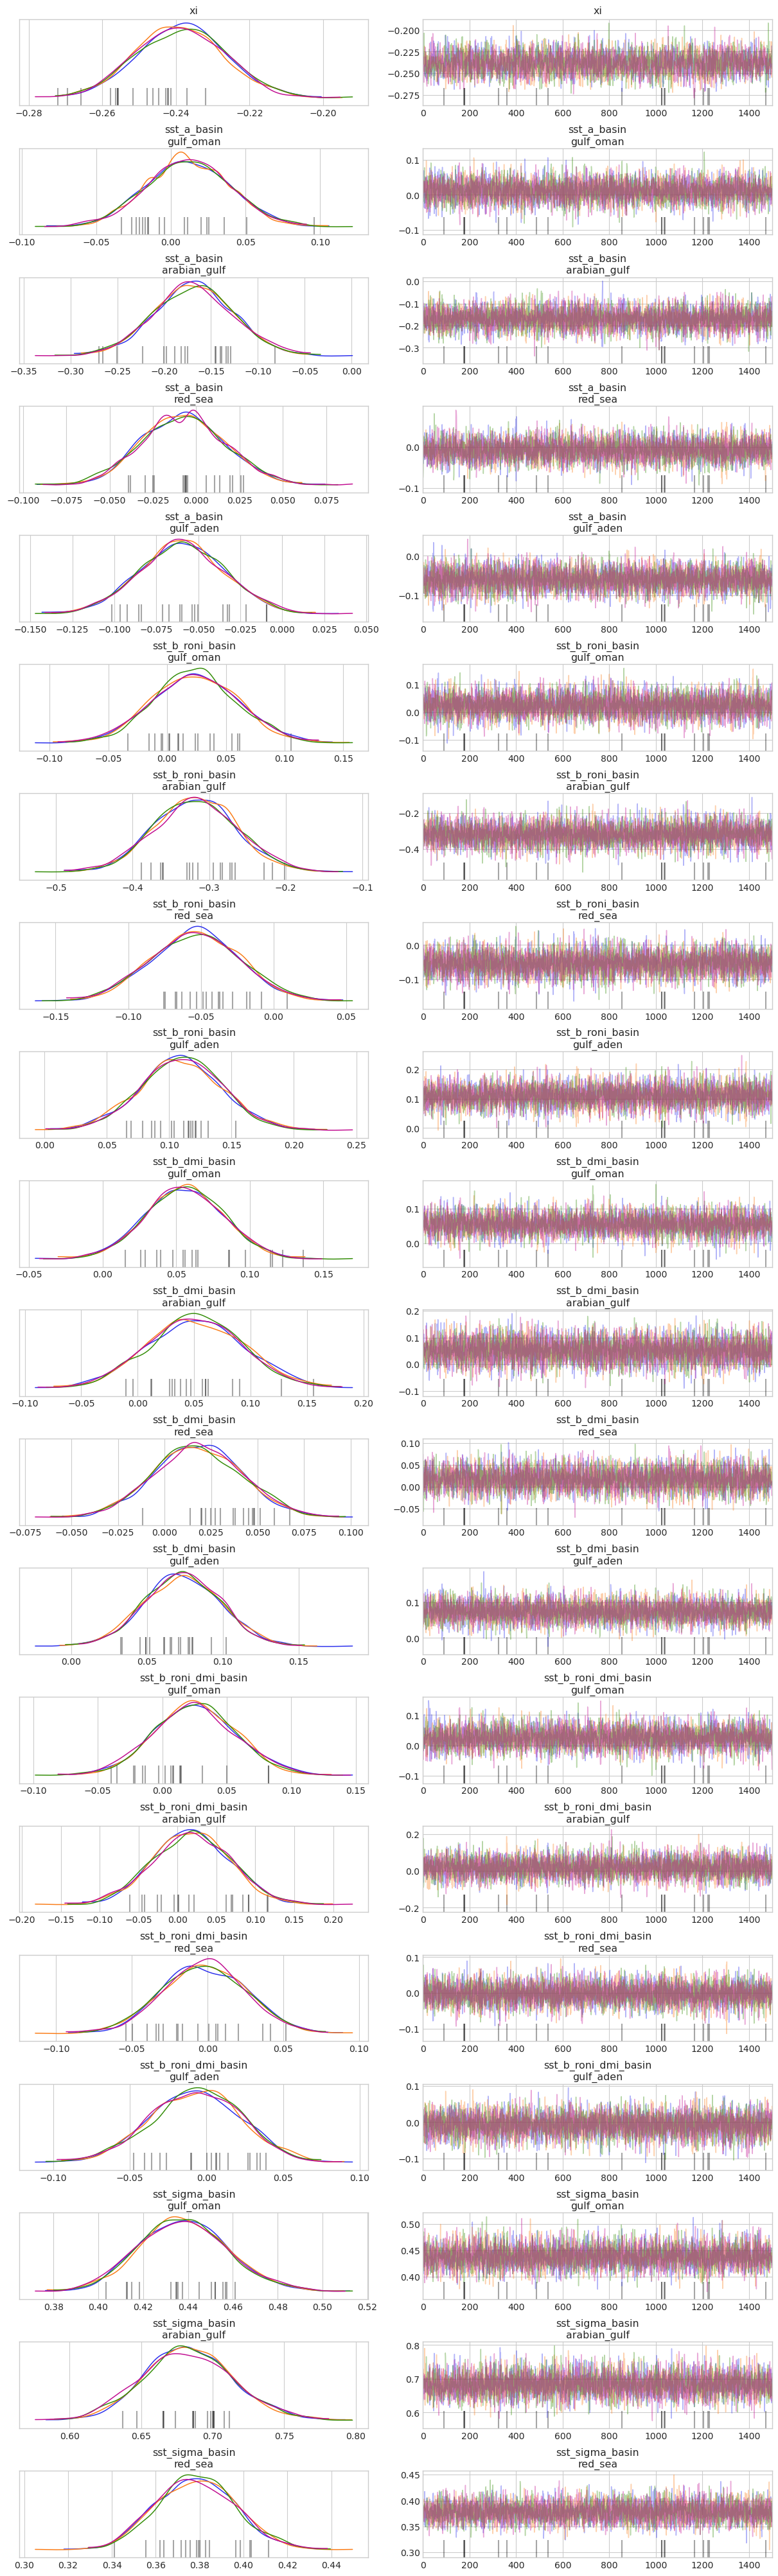

In [6]:
available = set(posterior.data_vars)

trace_vars = [
    name for name in [
        "xi",
        "sst_a_basin",
        "sst_b_roni_basin",
        "sst_b_dmi_basin",
        "sst_b_roni_dmi_basin",
        "sst_sigma_basin",
        "sst_nu",
    ]
    if name in available
]

az.plot_trace(idata, var_names=trace_vars, compact=False)
plt.tight_layout()
plt.show()


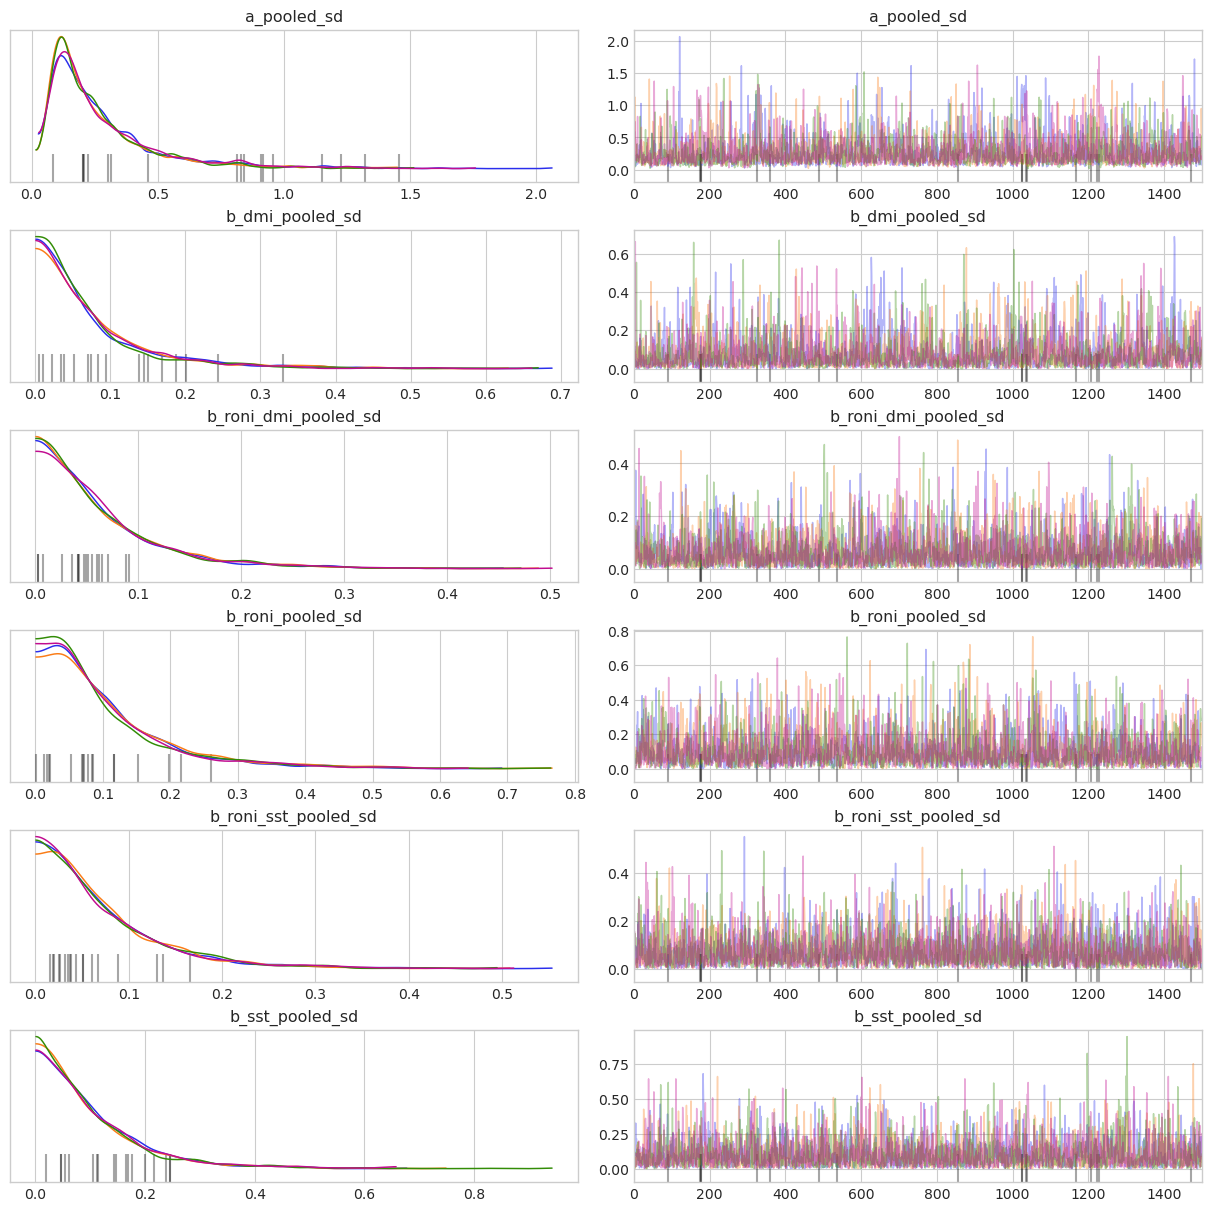

In [7]:
pooled_scale_vars = sorted(
    name for name in available
    if name.endswith("_pooled_sd")
)

if pooled_scale_vars:
    az.plot_trace(
        idata,
        var_names=pooled_scale_vars,
        compact=False,
    )
    plt.tight_layout()
    plt.show()
else:
    print("No pooled scale parameters found.")


## 4. Rank and energy plots

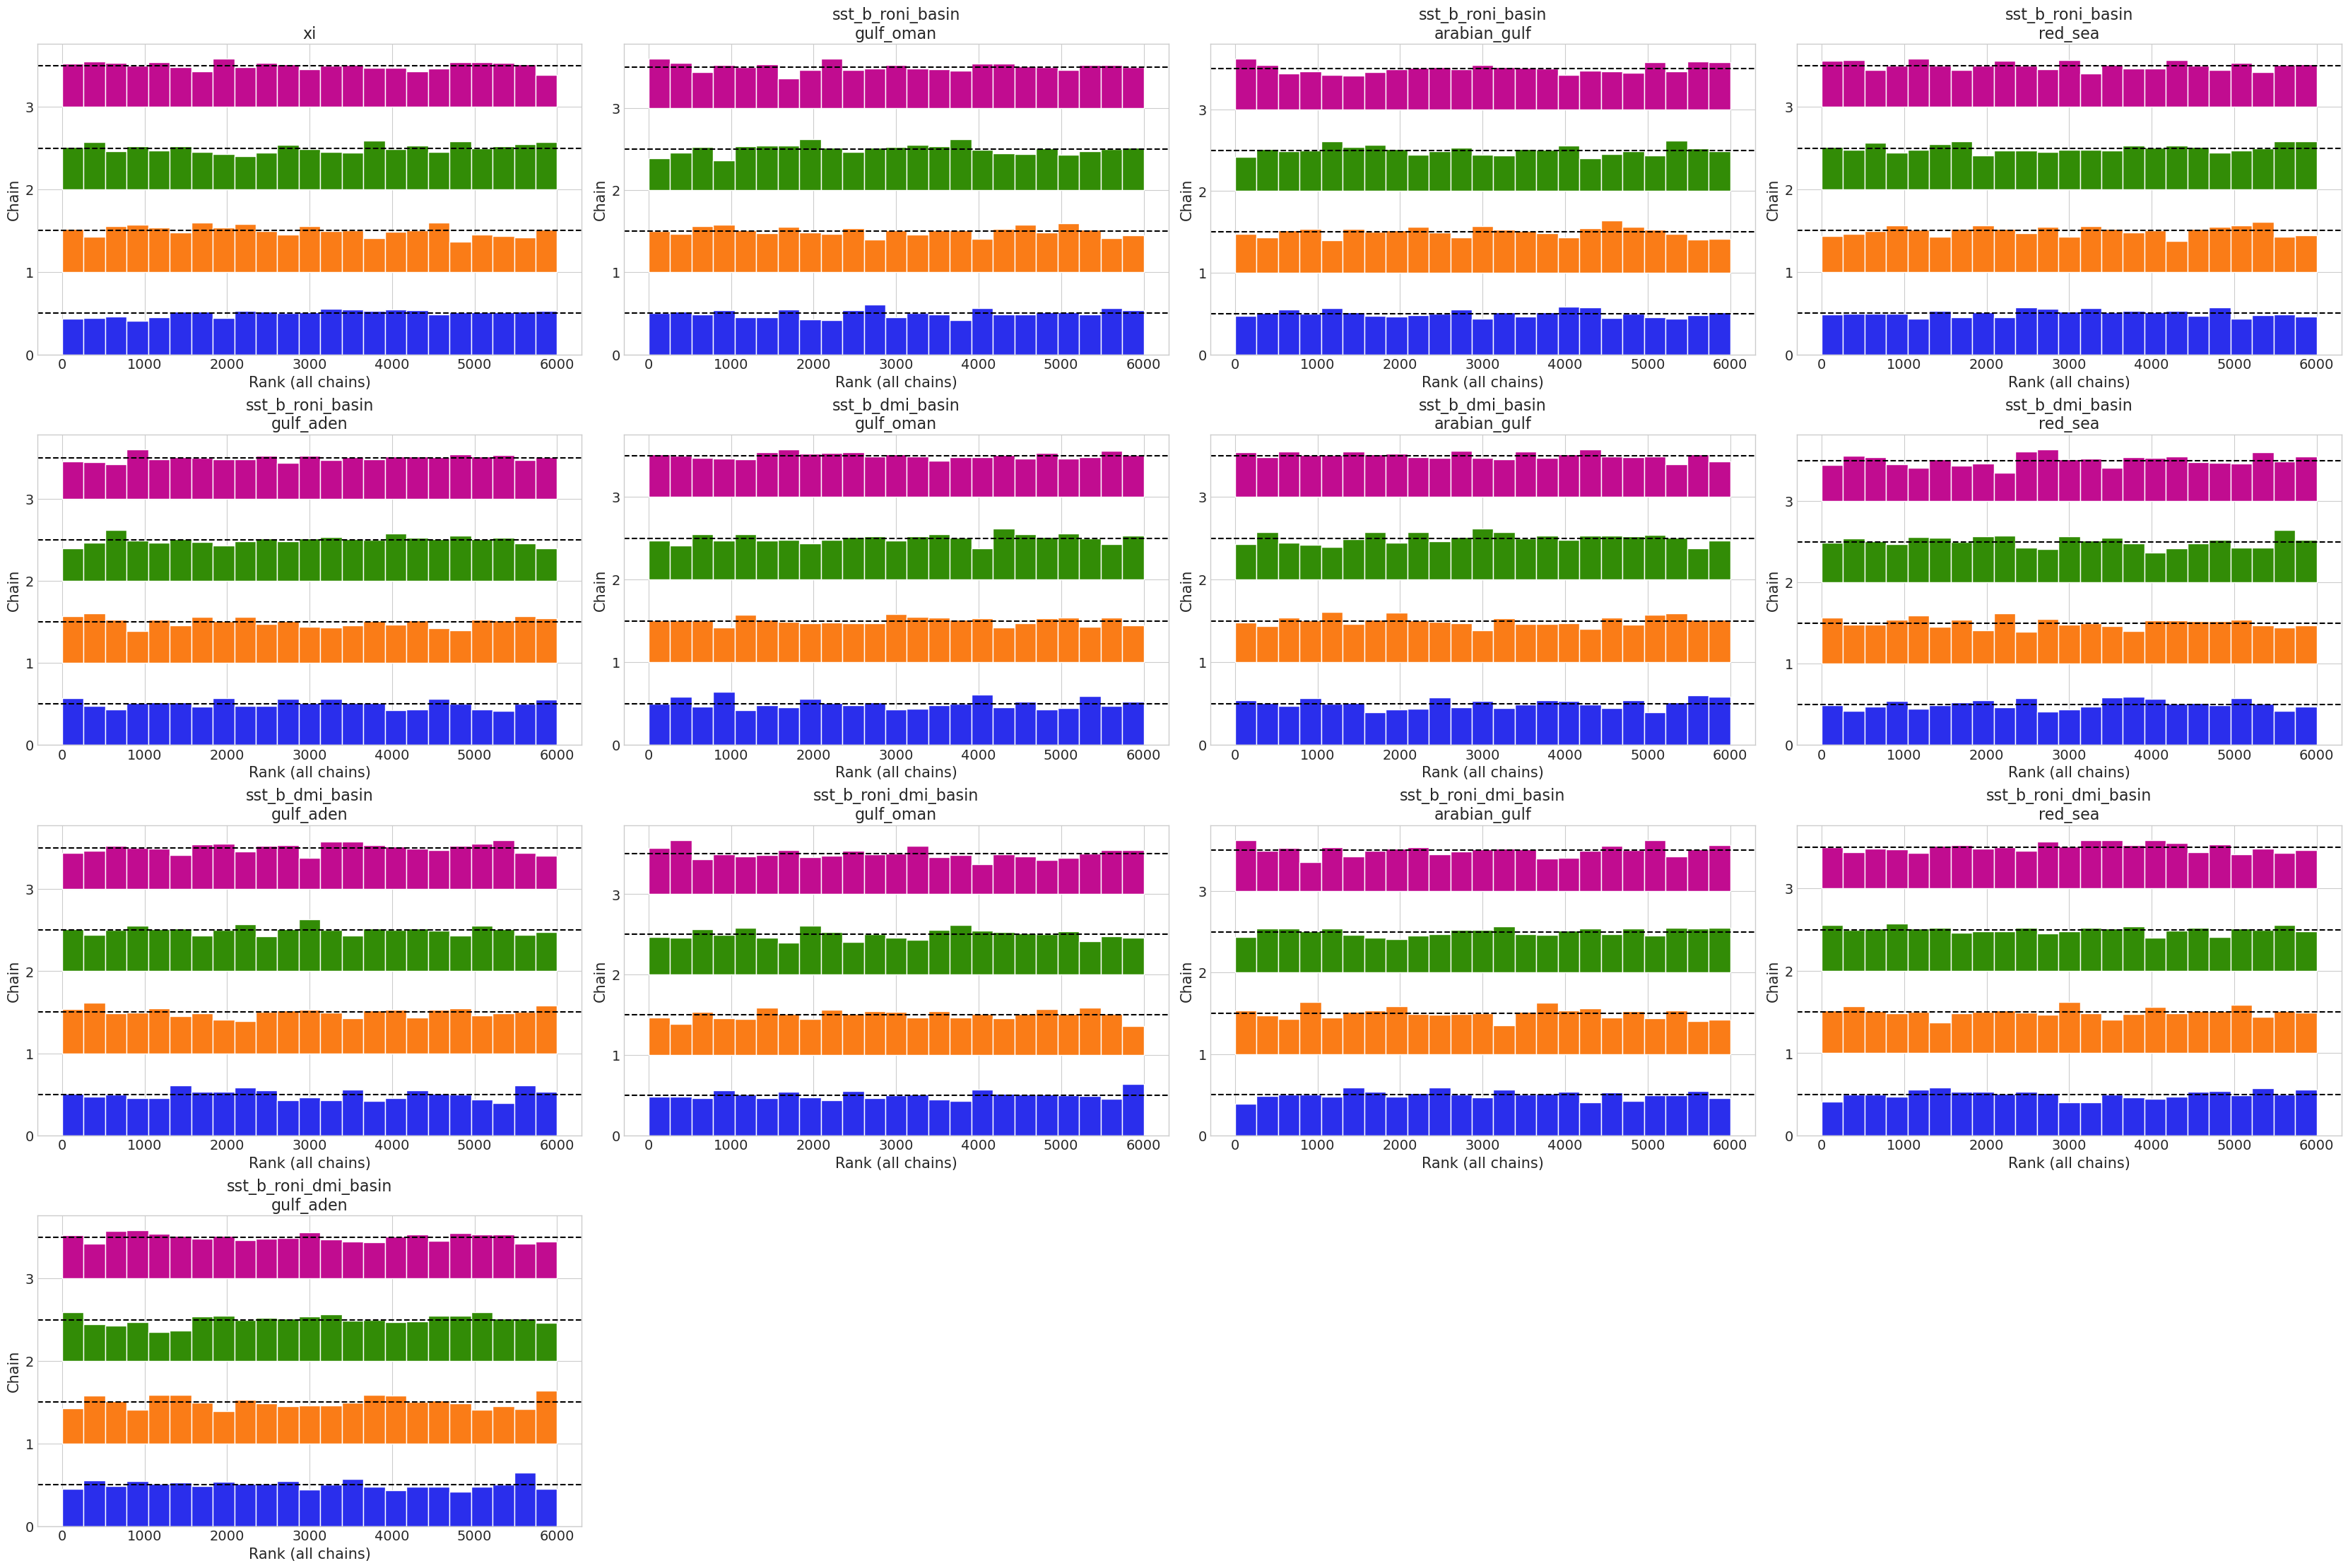

In [8]:
rank_vars = [
    name for name in [
        "xi",
        "sst_b_roni_basin",
        "sst_b_dmi_basin",
        "sst_b_roni_dmi_basin",
    ]
    if name in available
]

az.plot_rank(idata, var_names=rank_vars, kind="bars")
plt.tight_layout()
plt.show()


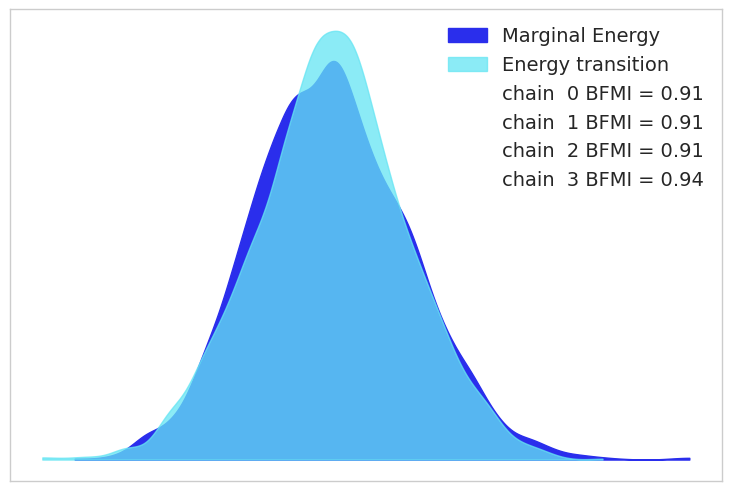

In [9]:
az.plot_energy(idata)
plt.tight_layout()
plt.show()


## 5. City-specific coefficient diagnostics

In [10]:
city_vars = [
    name for name in [
        "a_city",
        "b_roni_city",
        "b_dmi_city",
        "b_roni_dmi_city",
        "b_sst_city",
        "b_roni_sst_city",
    ]
    if name in available
]

city_diag = az.summary(
    idata,
    var_names=city_vars,
    kind="diagnostics",
    round_to=4,
)

display(city_diag)

city_diag_out = RUN_DIR / "joint_model_city_parameter_diagnostics.csv"
city_diag.to_csv(city_diag_out)
print("Saved:", city_diag_out)


/home/k16v981/.conda/envs/my_env/lib/python3.9/site-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/k16v981/.conda/envs/my_env/lib/python3.9/site-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a_city[muscat],0.0007,0.0005,4314.7941,5040.5733,1.0003
a_city[doha],0.0006,0.0004,5496.5472,5519.7136,0.9999
a_city[dubai],0.0005,0.0004,5521.1932,5357.1728,0.9999
a_city[jeddah],0.0008,0.0006,3948.1204,4204.8803,1.0007
a_city[aden],0.0008,0.0005,4276.3004,3849.3513,1.0007
a_city[medina],0.0006,0.0004,5650.2412,4630.6484,1.0002
a_city[riyadh],0.0006,0.0004,4595.0029,3286.4585,1.0002
a_city[dammam],0.0006,0.0005,5298.7012,4988.1470,1.0004
a_city[kuwait_city],0.0006,0.0005,5654.3904,4703.6295,0.9998
a_city[basra],0.0006,0.0004,5323.5786,4446.8213,1.0005


Saved: /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/joint_enso_local_sst_city_runs/joint_model_city_parameter_diagnostics.csv


## 6. Basin-specific coefficient diagnostics

In [11]:
basin_vars = [
    name for name in [
        "sst_a_basin",
        "sst_b_roni_basin",
        "sst_b_dmi_basin",
        "sst_b_roni_dmi_basin",
        "sst_sigma_basin",
    ]
    if name in available
]

basin_diag = az.summary(
    idata,
    var_names=basin_vars,
    kind="diagnostics",
    round_to=4,
)

basin_diag.index = [
    label.replace("arabian_gulf", "Persian Gulf")
    for label in basin_diag.index
]

display(basin_diag)

basin_diag_out = RUN_DIR / "joint_model_basin_parameter_diagnostics.csv"
basin_diag.to_csv(basin_diag_out)
print("Saved:", basin_diag_out)


,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sst_a_basin[gulf_oman],0.0004,0.0003,6051.1081,4708.8787,1.0009
sst_a_basin[Persian Gulf],0.0005,0.0004,7042.6581,4472.7213,1.0000
sst_a_basin[red_sea],0.0003,0.0003,6100.6522,4588.0052,0.9998
sst_a_basin[gulf_aden],0.0003,0.0002,7638.1099,4547.5673,0.9996
sst_b_roni_basin[gulf_oman],0.0004,0.0004,7490.6608,4576.0332,1.0003
sst_b_roni_basin[Persian Gulf],0.0006,0.0004,7822.7522,4738.2848,1.0008
sst_b_roni_basin[red_sea],0.0004,0.0003,7103.7884,4814.6971,1.0002
sst_b_roni_basin[gulf_aden],0.0004,0.0003,7892.7225,4235.9516,1.0009
sst_b_dmi_basin[gulf_oman],0.0003,0.0002,6784.9844,4482.4659,0.9997
sst_b_dmi_basin[Persian Gulf],0.0005,0.0004,7072.5475,5123.1217,1.0012


Saved: /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/joint_enso_local_sst_city_runs/joint_model_basin_parameter_diagnostics.csv


## 7. Final automated screen

In [12]:
max_rhat = float(summary["r_hat"].max())
min_bulk = float(summary["ess_bulk"].min())
min_tail = float(summary["ess_tail"].min())
min_bfmi = float(np.nanmin(bfmi))

print("FINAL DIAGNOSTIC SCREEN")
print("-" * 50)
print(f"Total divergences: {total_divergences}")
print(f"Maximum R-hat:      {max_rhat:.4f}")
print(f"Minimum bulk ESS:   {min_bulk:.1f}")
print(f"Minimum tail ESS:   {min_tail:.1f}")
print(f"Minimum BFMI:       {min_bfmi:.3f}")

passes = {
    "zero divergences": total_divergences == 0,
    "R-hat <= 1.01": max_rhat <= 1.01,
    "bulk ESS >= 400": min_bulk >= 400,
    "tail ESS >= 400": min_tail >= 400,
    "BFMI > 0.3": min_bfmi > 0.3,
}

print()
for test, passed in passes.items():
    print(f"{'PASS' if passed else 'CHECK'}: {test}")

if all(passes.values()):
    print(
        "\nThe model passes the selected numerical convergence screen. "
        "Still inspect the trace, rank, and energy plots."
    )
else:
    print(
        "\nAt least one diagnostic needs closer inspection. Use the "
        "problem-parameter table and plots above."
    )


FINAL DIAGNOSTIC SCREEN
--------------------------------------------------
Total divergences: 18
Maximum R-hat:      1.0040
Minimum bulk ESS:   1547.7
Minimum tail ESS:   1870.1
Minimum BFMI:       0.908

CHECK: zero divergences
PASS: R-hat <= 1.01
PASS: bulk ESS >= 400
PASS: tail ESS >= 400
PASS: BFMI > 0.3

At least one diagnostic needs closer inspection. Use the problem-parameter table and plots above.
